# Federated Learning con Flower e TensorFlow

Questo notebook implementa il federated learning usando Flower per il training di un modello CNN su Fashion-MNIST.

## Installazione delle dipendenze

Prima di iniziare, assicurati di avere installato le librerie necessarie:

In [1]:
# Installa le dipendenze necessarie (decommentare se necessario)
# !pip install flwr tensorflow matplotlib

## Import delle librerie

In [1]:
print("test")
import os
import sys
import threading
import time
from typing import Tuple
import multiprocessing as mp

import numpy as np
import tensorflow as tf
from tensorflow import keras
import flwr as fl
import matplotlib.pyplot as plt

# Silenzia i log di TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
tf.get_logger().setLevel('ERROR')

print("Librerie importate con successo!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Flower version: {fl.__version__}")

test


2025-07-21 12:59:23.901544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753102763.916804   90445 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753102763.921183   90445 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753102763.933299   90445 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753102763.933315   90445 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753102763.933318   90445 computation_placer.cc:177] computation placer alr

ModuleNotFoundError: No module named 'flwr'

## Configurazione degli iperparametri

In [3]:
# Iperparametri e costanti
NUM_CLIENTS = 5         # Numero totale di client
ROUNDS = 5              # Round di federated learning
LOCAL_EPOCHS = 1        # Epoche SGD per client per round
BATCH_SIZE = 32         # Dimensione del batch SGD
SEED = 42               # Per la riproducibilità

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Configurazione:")
print(f"- Numero di client: {NUM_CLIENTS}")
print(f"- Round di training: {ROUNDS}")
print(f"- Epoche locali: {LOCAL_EPOCHS}")
print(f"- Batch size: {BATCH_SIZE}")

Configurazione:
- Numero di client: 5
- Round di training: 5
- Epoche locali: 1
- Batch size: 32


## Funzioni per il caricamento e partizionamento dei dati

In [4]:
def load_partition(cid: int) -> Tuple[Tuple[np.ndarray, np.ndarray], Tuple[np.ndarray, np.ndarray]]:
    """
    Restituisce la suddivisione locale train/test per un dato client id (cid).
    
    Viene eseguita una suddivisione IID semplice mescolando il set di training globale
    e dividendolo in NUM_CLIENTS parti approssimativamente uguali.
    """
    (x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

    # Pre-processing identico allo script originale
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    x_train = x_train.reshape(-1, 28, 28, 1)
    x_test = x_test.reshape(-1, 28, 28, 1)

    # Partizionamento IID — deterministico per cid
    size_per_client = len(x_train) // NUM_CLIENTS
    start, end = cid * size_per_client, (cid + 1) * size_per_client
    x_train_part, y_train_part = x_train[start:end], y_train[start:end]

    return (x_train_part, y_train_part), (x_test, y_test)

# Test della funzione di partizionamento
print("Testing data partitioning...")
(x_train_0, y_train_0), (x_test_0, y_test_0) = load_partition(0)
print(f"Client 0 - Training samples: {len(x_train_0)}, Test samples: {len(x_test_0)}")
print(f"Training data shape: {x_train_0.shape}, Labels shape: {y_train_0.shape}")

Testing data partitioning...
Client 0 - Training samples: 12000, Test samples: 10000
Training data shape: (12000, 28, 28, 1), Labels shape: (12000,)


## Visualizzazione di alcuni esempi dal dataset

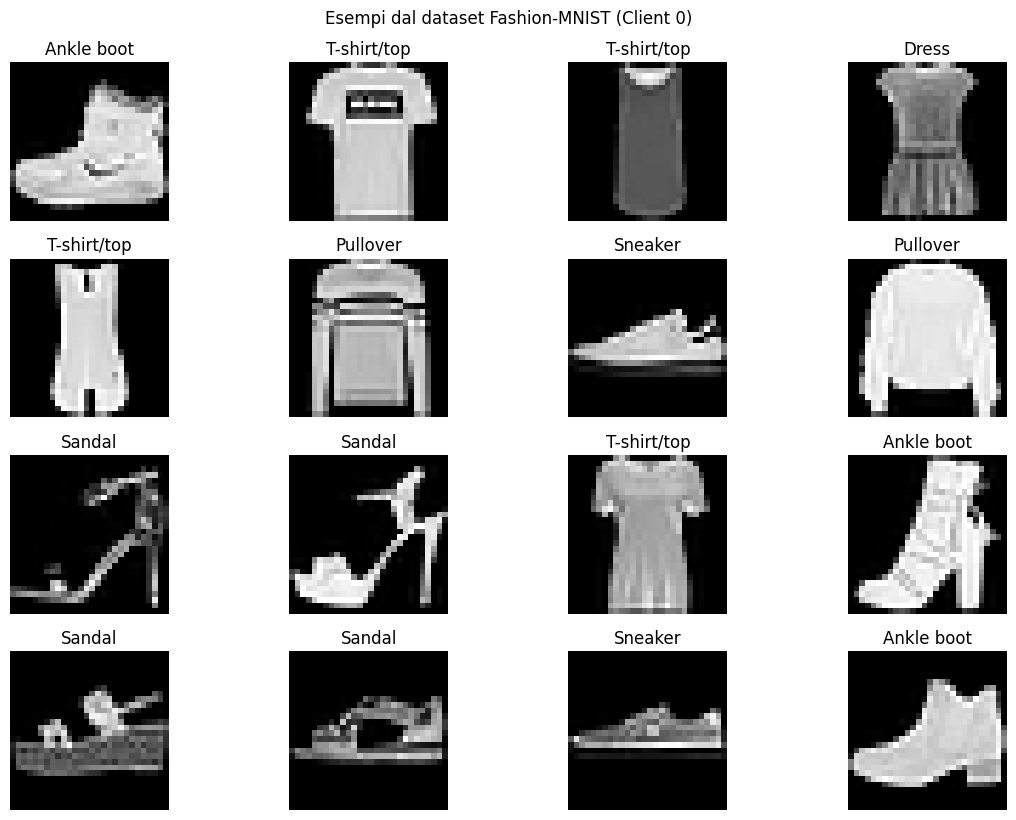

In [5]:
# Nomi delle classi Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualizza alcuni esempi
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train_0[i].reshape(28, 28), cmap='gray')
    plt.title(f'{class_names[y_train_0[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Esempi dal dataset Fashion-MNIST (Client 0)', y=1.02)
plt.show()

## Definizione del modello

In [6]:
def build_model() -> keras.Model:
    """
    Costruisce il modello CNN per Fashion-MNIST.
    """
    model = keras.Sequential([
        keras.layers.Conv2D(filters=8, kernel_size=3, strides=2, activation="relu", 
                           input_shape=(28, 28, 1), name="Conv1"),
        keras.layers.Flatten(),
        keras.layers.Dense(10, activation="softmax", name="Softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# Test del modello
test_model = build_model()
test_model.summary()

# Test con dati dummy
dummy_input = np.random.random((1, 28, 28, 1))
dummy_output = test_model.predict(dummy_input, verbose=0)
print(f"\nOutput shape: {dummy_output.shape}")
print(f"Output probabilities sum: {dummy_output.sum():.4f}")

/home/zerod/lab/jupyterlab/jupyter-extension-project/jupyter-workflow/examples/tensorflow/work/TestTrainingModelOld/fedenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 13, 13, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Softmax (Dense)                 │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)


Output shape: (1, 10)
Output probabilities sum: 1.0000


## Classe Client per Flower

In [7]:
class FashionClient(fl.client.NumPyClient):
    """
    Client Flower che implementa l'API NumPyClient.
    """

    def __init__(self, cid: int):
        self.cid = cid
        (self.x_train, self.y_train), (self.x_test, self.y_test) = load_partition(cid)
        self.model = build_model()
        print(f"Client {cid} inizializzato con {len(self.x_train)} campioni di training")

    def get_parameters(self, config):
        """Restituisce i parametri del modello."""
        return self.model.get_weights()

    def fit(self, parameters, config):
        """Training locale del modello."""
        self.model.set_weights(parameters)
        
        history = self.model.fit(
            self.x_train,
            self.y_train,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
        )
        
        # Stampa statistiche di training
        final_loss = history.history['loss'][-1]
        final_acc = history.history['accuracy'][-1]
        print(f"Client {self.cid} - Training Loss: {final_loss:.4f}, Accuracy: {final_acc:.4f}")
        
        return self.model.get_weights(), len(self.x_train), {}

    def evaluate(self, parameters, config):
        """Valutazione del modello."""
        self.model.set_weights(parameters)
        loss, acc = self.model.evaluate(self.x_test, self.y_test, verbose=0)
        print(f"Client {self.cid} - Evaluation Loss: {loss:.4f}, Accuracy: {acc:.4f}")
        return loss, len(self.x_test), {"accuracy": acc}

# Test della classe client
print("Testing FashionClient...")
test_client = FashionClient(0)
initial_params = test_client.get_parameters({})
print(f"Numero di layer con parametri: {len(initial_params)}")

Testing FashionClient...
Client 0 inizializzato con 12000 campioni di training
Numero di layer con parametri: 4


## Funzioni per avviare Server e Client

In [8]:
def start_server():
    """
    Avvia il server centrale Flower (aggregatore).
    """
    strategy = fl.server.strategy.FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=NUM_CLIENTS,
        min_available_clients=NUM_CLIENTS,
        min_evaluate_clients=NUM_CLIENTS,
    )

    print(f"Avvio server Flower su 0.0.0.0:8080...")
    print(f"In attesa di {NUM_CLIENTS} client per {ROUNDS} round")
    
    fl.server.start_server(
        server_address="0.0.0.0:8080",
        config=fl.server.ServerConfig(num_rounds=ROUNDS),
        strategy=strategy,
    )

def start_client(cid: int):
    """
    Avvia un client e si connette al server Flower.
    """
    print(f"Avvio client {cid}...")
    fl.client.start_numpy_client(
        server_address="0.0.0.0:8080", 
        client=FashionClient(cid)
    )

print("Funzioni server e client definite.")

Funzioni server e client definite.


## Simulazione del Federated Learning

**Attenzione**: La simulazione in un notebook può essere complessa a causa delle limitazioni nell'esecuzione di processi multipli. Questo esempio usa il simulatore integrato di Flower per una dimostrazione semplificata.

In [9]:
def client_fn(cid: str) -> FashionClient:
    """
    Factory function per creare un client.
    """
    return FashionClient(int(cid))

# Configurazione della strategia
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
)

print("Configurazione simulazione pronta.")
print("Per avviare la simulazione, esegui la cella successiva.")

Configurazione simulazione pronta.
Per avviare la simulazione, esegui la cella successiva.


In [10]:
# Avvia la simulazione del federated learning
print("🚀 Avvio simulazione Federated Learning...")
print(f"Configurazione: {NUM_CLIENTS} client, {ROUNDS} round, {LOCAL_EPOCHS} epoche locali")
print("=" * 60)

# Usa il simulatore di Flower
history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=ROUNDS),
    strategy=strategy,
)

print("\n✅ Simulazione completata!")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


🚀 Avvio simulazione Federated Learning...
Configurazione: 5 client, 5 round, 1 epoche locali


2025-07-21 10:40:35,905	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:192.168.1.100': 1.0, 'CPU': 16.0, 'memory': 12163212903.0, 'object_store_memory': 6081606451.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      No `client_resources` specified. Using minimal resources for clients.
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 16 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(ClientAppActor pid=14848) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(Client

(ClientAppActor pid=14848) Client 1 inizializzato con 12000 campioni di training
(ClientAppActor pid=14848) Client 2 inizializzato con 12000 campioni di training


(ClientAppActor pid=14848) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)


...

(ClientAppActor pid=14847) Client 3 inizializzato con 12000 campioni di training [repeated 21x across cluster]


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 5 clients (out of 5)
(ClientAppActor pid=14846) 
(ClientAppActor pid=14846)         
(ClientAppActor pid=14845) 
(ClientAppActor pid=14845)         
(ClientAppActor pid=14847) 
(ClientAppActor pid=14847)         
(ClientAppActor pid=14844) 
(ClientAppActor pid=14844)         
(ClientAppActor pid=14848) 
(ClientAppActor pid=14848)         


(ClientAppActor pid=14848) Client 4 - Training Loss: 0.4362, Accuracy: 0.8481 [repeated 14x across cluster]


INFO :      aggregate_evaluate: received 5 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 12.63s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.5703923106193542
INFO :      		round 2: 0.5022611021995544
INFO :      		round 3: 0.47238534688949585
INFO :      		round 4: 0.4501839280128479
INFO :      		round 5: 0.43351978063583374
INFO :      



✅ Simulazione completata!
(ClientAppActor pid=14847) Client 2 - Evaluation Loss: 0.4335, Accuracy: 0.8491


## Visualizzazione dei risultati

In [11]:
print(history.losses_distributed)
print(history.metrics_distributed)
print(history.metrics_centralized)
print(history)
loss_list = [loss for (_, loss) in history.losses_distributed]
loss_array = np.array(loss_list)
print(loss_array)
print(loss_list)


[(1, 0.5703923106193542), (2, 0.5022611021995544), (3, 0.47238534688949585), (4, 0.4501839280128479), (5, 0.43351978063583374)]
{}
{}
History (loss, distributed):
	round 1: 0.5703923106193542
	round 2: 0.5022611021995544
	round 3: 0.47238534688949585
	round 4: 0.4501839280128479
	round 5: 0.43351978063583374

[0.57039231 0.5022611  0.47238535 0.45018393 0.43351978]
[0.5703923106193542, 0.5022611021995544, 0.47238534688949585, 0.4501839280128479, 0.43351978063583374]


In [14]:
# Estrai le metriche dalla history
rounds=[]
losses = []
accuracies = []

for round_num, (loss, metrics) in history.metrics_distributed.items():
    rounds.append(round_num)
    losses.append(loss)
    if 'accuracy' in metrics:
        accuracies.append(metrics['accuracy'])
losses = [loss for (_, loss) in history.losses_distributed]




# Stampa statistiche finali
print("\n📊 Risultati Finali:")
print("=" * 30)
if losses:
    print(f"Loss iniziale: {losses[0]:.4f}")
    print(f"Loss finale: {losses[-1]:.4f}")
    print(f"Miglioramento loss: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

if accuracies:
    print(f"Accuracy iniziale: {accuracies[0]:.4f}")
    print(f"Accuracy finale: {accuracies[-1]:.4f}")
    print(f"Miglioramento accuracy: {((accuracies[-1] - accuracies[0]) * 100):.2f} punti percentuali")


📊 Risultati Finali:
Loss iniziale: 0.5704
Loss finale: 0.4335
Miglioramento loss: 24.00%


## Test del modello finale

Testiamo le performance del modello aggregato finale su alcuni esempi:

/home/zerod/lab/jupyterlab/jupyter-extension-project/jupyter-workflow/examples/tensorflow/work/TestTrainingModelOld/fedenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Client 0 inizializzato con 12000 campioni di training


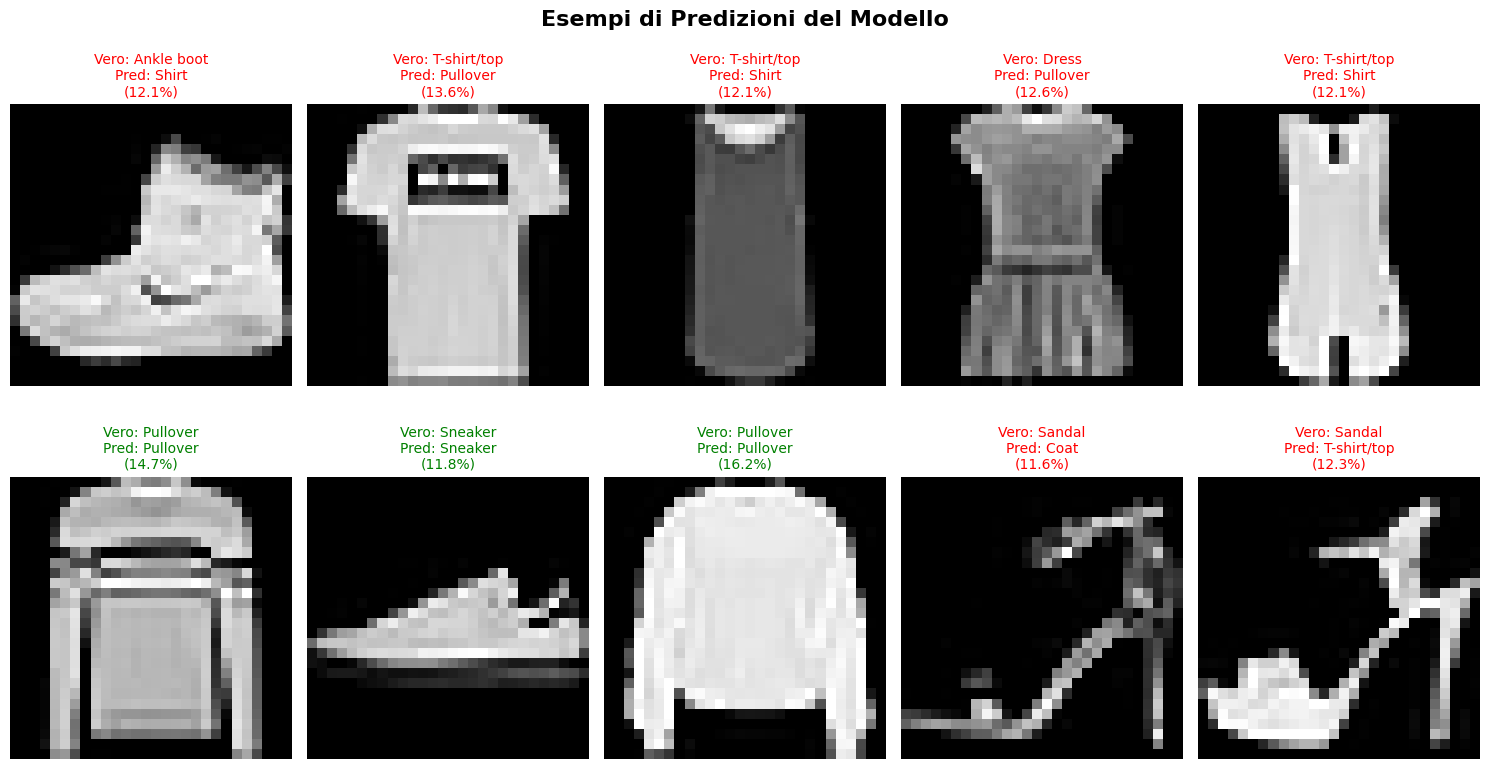


Accuracy sui 10 campioni di test: 0.3000 (30.0%)


In [15]:
# Crea un modello finale e testa le predizioni
final_model = build_model()

# Se hai accesso ai pesi finali dalla simulazione, puoi usarli qui
# Per ora, usiamo un client per ottenere dei pesi di esempio
test_client = FashionClient(0)
(x_test_sample, y_test_sample), _ = load_partition(0)

# Prendi i primi 10 esempi per il test
x_sample = x_test_sample[:10]
y_true = y_test_sample[:10]

# Fai predizioni
predictions = final_model.predict(x_sample, verbose=0)
y_pred = np.argmax(predictions, axis=1)

# Visualizza i risultati
plt.figure(figsize=(15, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_sample[i].reshape(28, 28), cmap='gray')
    
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    confidence = predictions[i][y_pred[i]] * 100
    
    color = 'green' if y_true[i] == y_pred[i] else 'red'
    plt.title(f'Vero: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)', 
              color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Esempi di Predizioni del Modello', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Calcola l'accuracy sui campioni di test
accuracy = np.mean(y_true == y_pred)
print(f"\nAccuracy sui {len(x_sample)} campioni di test: {accuracy:.4f} ({accuracy*100:.1f}%)")

## Confronto con Training Centralizzato

Vediamo come si comporta il training centralizzato tradizionale per confronto:

In [16]:
# Training centralizzato per confronto
print("🔄 Training centralizzato per confronto...")

# Carica tutti i dati
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()
x_train_full = x_train_full.astype("float32") / 255.0
x_test_full = x_test_full.astype("float32") / 255.0
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test_full = x_test_full.reshape(-1, 28, 28, 1)

# Crea e addestra il modello centralizzato
centralized_model = build_model()
centralized_history = centralized_model.fit(
    x_train_full, y_train_full,
    epochs=ROUNDS * LOCAL_EPOCHS,  # Stesso numero totale di epoche
    batch_size=BATCH_SIZE,
    validation_data=(x_test_full, y_test_full),
    verbose=1
)

print("\n✅ Training centralizzato completato!")


🔄 Training centralizzato per confronto...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7531 - loss: 0.7278 - val_accuracy: 0.8390 - val_loss: 0.4553
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8519 - loss: 0.4256 - val_accuracy: 0.8550 - val_loss: 0.4086
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8668 - loss: 0.3814 - val_accuracy: 0.8627 - val_loss: 0.3882
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8735 - loss: 0.3566 - val_accuracy: 0.8689 - val_loss: 0.3760
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8785 - loss: 0.3401 - val_accuracy: 0.8710 - val_loss: 0.3683

✅ Training centralizzato completato!

🏆 Confronto Performance:
Training Centralizzato - Accuracy finale: 0.8710
Training Centralizzato - Loss finale: 0.3683


In [17]:

# Confronta le performance
centralized_final_acc = centralized_history.history['val_accuracy'][-1]
centralized_final_loss = centralized_history.history['val_loss'][-1]

print("\n🏆 Confronto Performance:")
print("=" * 40)
print(f"Training Centralizzato - Accuracy finale: {centralized_final_acc:.4f}")
print(f"Training Centralizzato - Loss finale: {centralized_final_loss:.4f}")

if losses:
    print(f"Federated Learning - Loss finale: {losses[-1]:.4f}")
    
    loss_diff = ((centralized_final_loss - losses[-1]) / centralized_final_loss) * 100
    
    print(f"Differenza Loss: {loss_diff:+.2f}%")


🏆 Confronto Performance:
Training Centralizzato - Accuracy finale: 0.8710
Training Centralizzato - Loss finale: 0.3683
Federated Learning - Loss finale: 0.4335
Differenza Loss: -17.70%


## Conclusioni

Questo notebook ha dimostrato come implementare il federated learning usando Flower e TensorFlow. 

### Vantaggi del Federated Learning:
- **Privacy**: I dati rimangono sui dispositivi locali
- **Scalabilità**: Può gestire molti client in parallelo
- **Robustezza**: Continua a funzionare anche se alcuni client si disconnettono

### Considerazioni:
- Le performance possono essere leggermente inferiori al training centralizzato
- La comunicazione tra server e client introduce overhead
- La distribuzione non-IID dei dati può influenzare le performance

### Prossimi passi:
- Sperimentare con strategie di aggregazione diverse
- Implementare la distribuzione non-IID dei dati
- Aggiungere meccanismi di privacy come differential privacy